# Exercise 4: June 12, 2025

# Plotting Images, Working With 2-D Data Sets

# Plotting Climate Data

**Question 1.** Let's plot some climate data. I've included average temperature anomalies for the United States and the world in the assignment. The format of the .csv files is: column 1- year; column 2- temperature anomaly; column 3- a smoothed fit to the yearly temperature anomaly data. In the Python counting system these will be columns 0, 1, and 2 respectively!

Make two different plots showing the temperature anomalies first as a line plot, and then as a bar plot where the bars are colored based on the temperature anomaly. I've included two examples below. Your plots don't have to look exactly the same; you can experiment with different colors, markers, linesytles, etc.

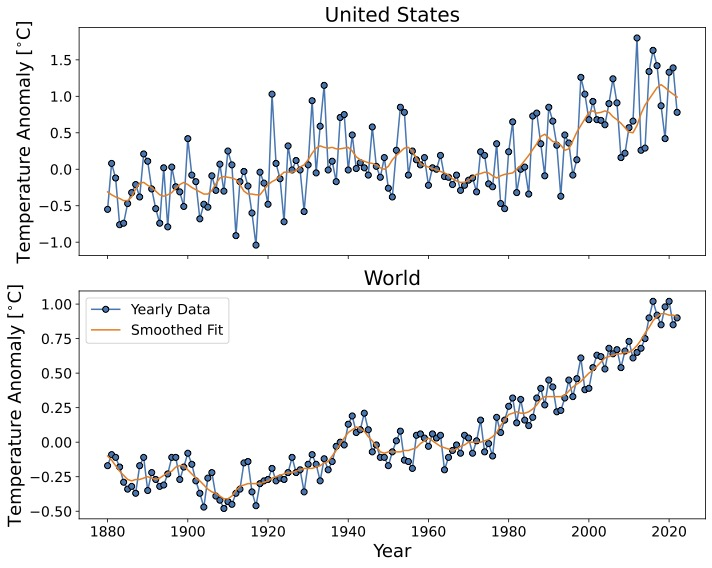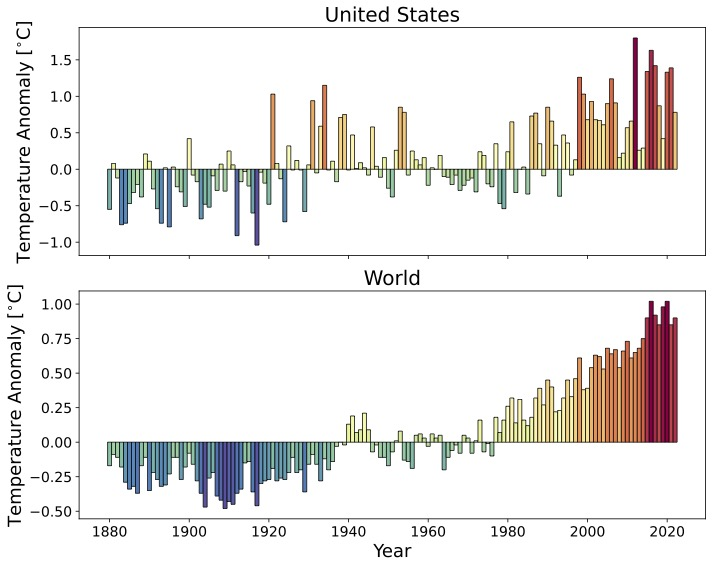

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib as mpl

In [2]:
from google.colab import files
files.upload()
us_temp = np.loadtxt("us_temperature_anomalies.csv", skiprows=(2), usecols=(0,1,2), delimiter=",", unpack=True)

Saving us_temperature_anomalies.csv to us_temperature_anomalies.csv


In [3]:
from google.colab import files
files.upload()
w_temp = np.loadtxt("world_temperature_anomalies.csv", skiprows=(3), usecols=(0,1,2), delimiter=",", unpack=True)

Saving world_temperature_anomalies.csv to world_temperature_anomalies.csv


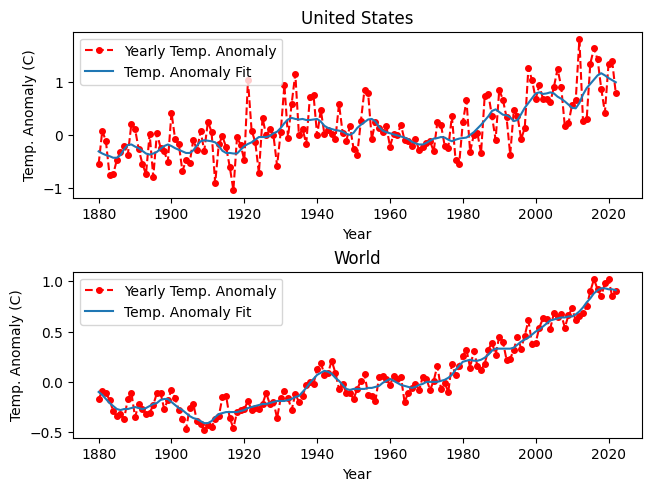

In [4]:
year1 = us_temp[0]
temp_anom1 = us_temp[1]
fit1 = us_temp[2]

year2 = w_temp[0]
temp_anom2 = w_temp[1]
fit2 = w_temp[2]

fig, (ax1, ax2) = plt.subplots(2,1, layout="constrained")
ax1.plot(year1,temp_anom1,"ro--", year1,fit1, markersize=4)
ax1.legend(["Yearly Temp. Anomaly", "Temp. Anomaly Fit"])
ax1.set_xlabel("Year")
ax1.set_ylabel("Temp. Anomaly (C)")
ax1.set_title("United States")

ax2.plot(year2,temp_anom2,"ro--", year2,fit2, markersize=4)
ax2.legend(["Yearly Temp. Anomaly", "Temp. Anomaly Fit"])
ax2.set_xlabel("Year")
ax2.set_ylabel("Temp. Anomaly (C)")
ax2.set_title("World")

plt.show()

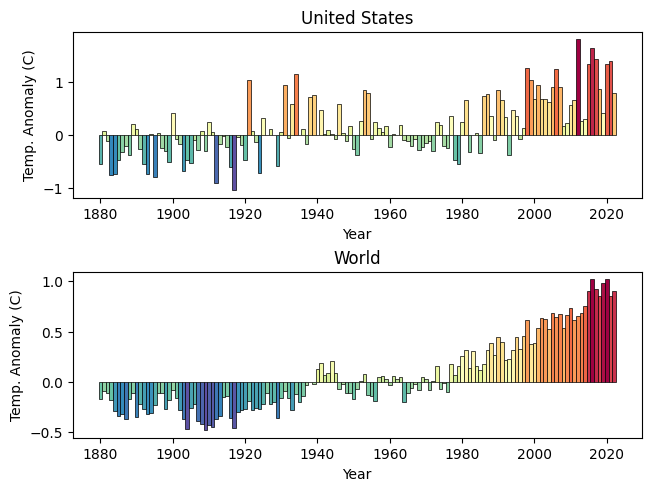

In [5]:
cmap = plt.get_cmap("Spectral_r")
rescale = lambda y: (y-np.min(y)) / (np.max(y) - np.min(y))

fig, (a1, a2) = plt.subplots(2,1, layout="constrained")

a1.bar(year1, temp_anom1, width=1, edgecolor="black", linewidth=0.5, color=cmap(rescale(temp_anom1)))
a1.set_xlabel("Year")
a1.set_ylabel("Temp. Anomaly (C)")
a1.set_title("United States")

a2.bar(year2, temp_anom2, width=1, edgecolor="black", linewidth=0.5, color=cmap(rescale(temp_anom2)))
a2.set_xlabel("Year")
a2.set_ylabel("Temp. Anomaly (C)")
a2.set_title("World")

plt.show()

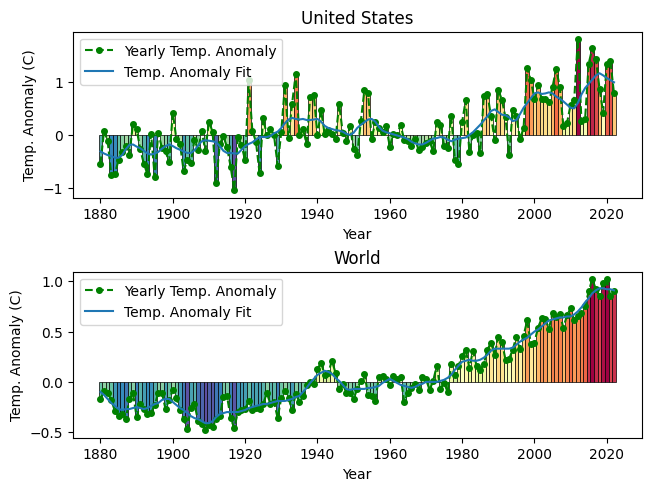

In [6]:
cmap = plt.get_cmap("Spectral_r")
rescale = lambda y: (y-np.min(y)) / (np.max(y) - np.min(y))

fig, (a1, a2) = plt.subplots(2,1, layout="constrained")

a1.bar(year1, temp_anom1, width=1, edgecolor="black", linewidth=0.5, color=cmap(rescale(temp_anom1)))
a1.plot(year1,temp_anom1,"go--", year1,fit1, markersize=4)
a1.legend(["Yearly Temp. Anomaly", "Temp. Anomaly Fit"])
a1.set_xlabel("Year")
a1.set_ylabel("Temp. Anomaly (C)")
a1.set_title("United States")

a2.bar(year2, temp_anom2, width=1, edgecolor="black", linewidth=0.5, color=cmap(rescale(temp_anom2)))
a2.plot(year2,temp_anom2,"go--", year2,fit2, markersize=4)
a2.legend(["Yearly Temp. Anomaly", "Temp. Anomaly Fit"])
a2.set_xlabel("Year")
a2.set_ylabel("Temp. Anomaly (C)")
a2.set_title("World")

plt.show()

Which plot (the US temperature anomalies or the world temperature anomalies) shows a more clear warming signal? Why do you think that is?

**The world temperature anomalies show a more clear warming signal. I believe this is because it displays cumulative data for the globe rather than just a certain region of the Earth.**

# Mantle Convection Model Images

**Question 2.** Make a figure with two subplots, one showing the temperature field and a second showing the viscosity field. Use the data file f000, where in the Python counting system column 0 is the x-coordinate, column 1 is the y-coordinate, column 2 is temperature, and column 5 is the viscosity. You can follow the example I gave in the lecture notebook. Include colorbars and the viscosity field should be plotted with a logscale color map. The x-axis goes from 0 to 4, while the y-axis goes from 0 to 1, so make the plots have an aspect ratio of 4. Here's an example (feel free to try different colorscales or other cosmetic features of the plot):

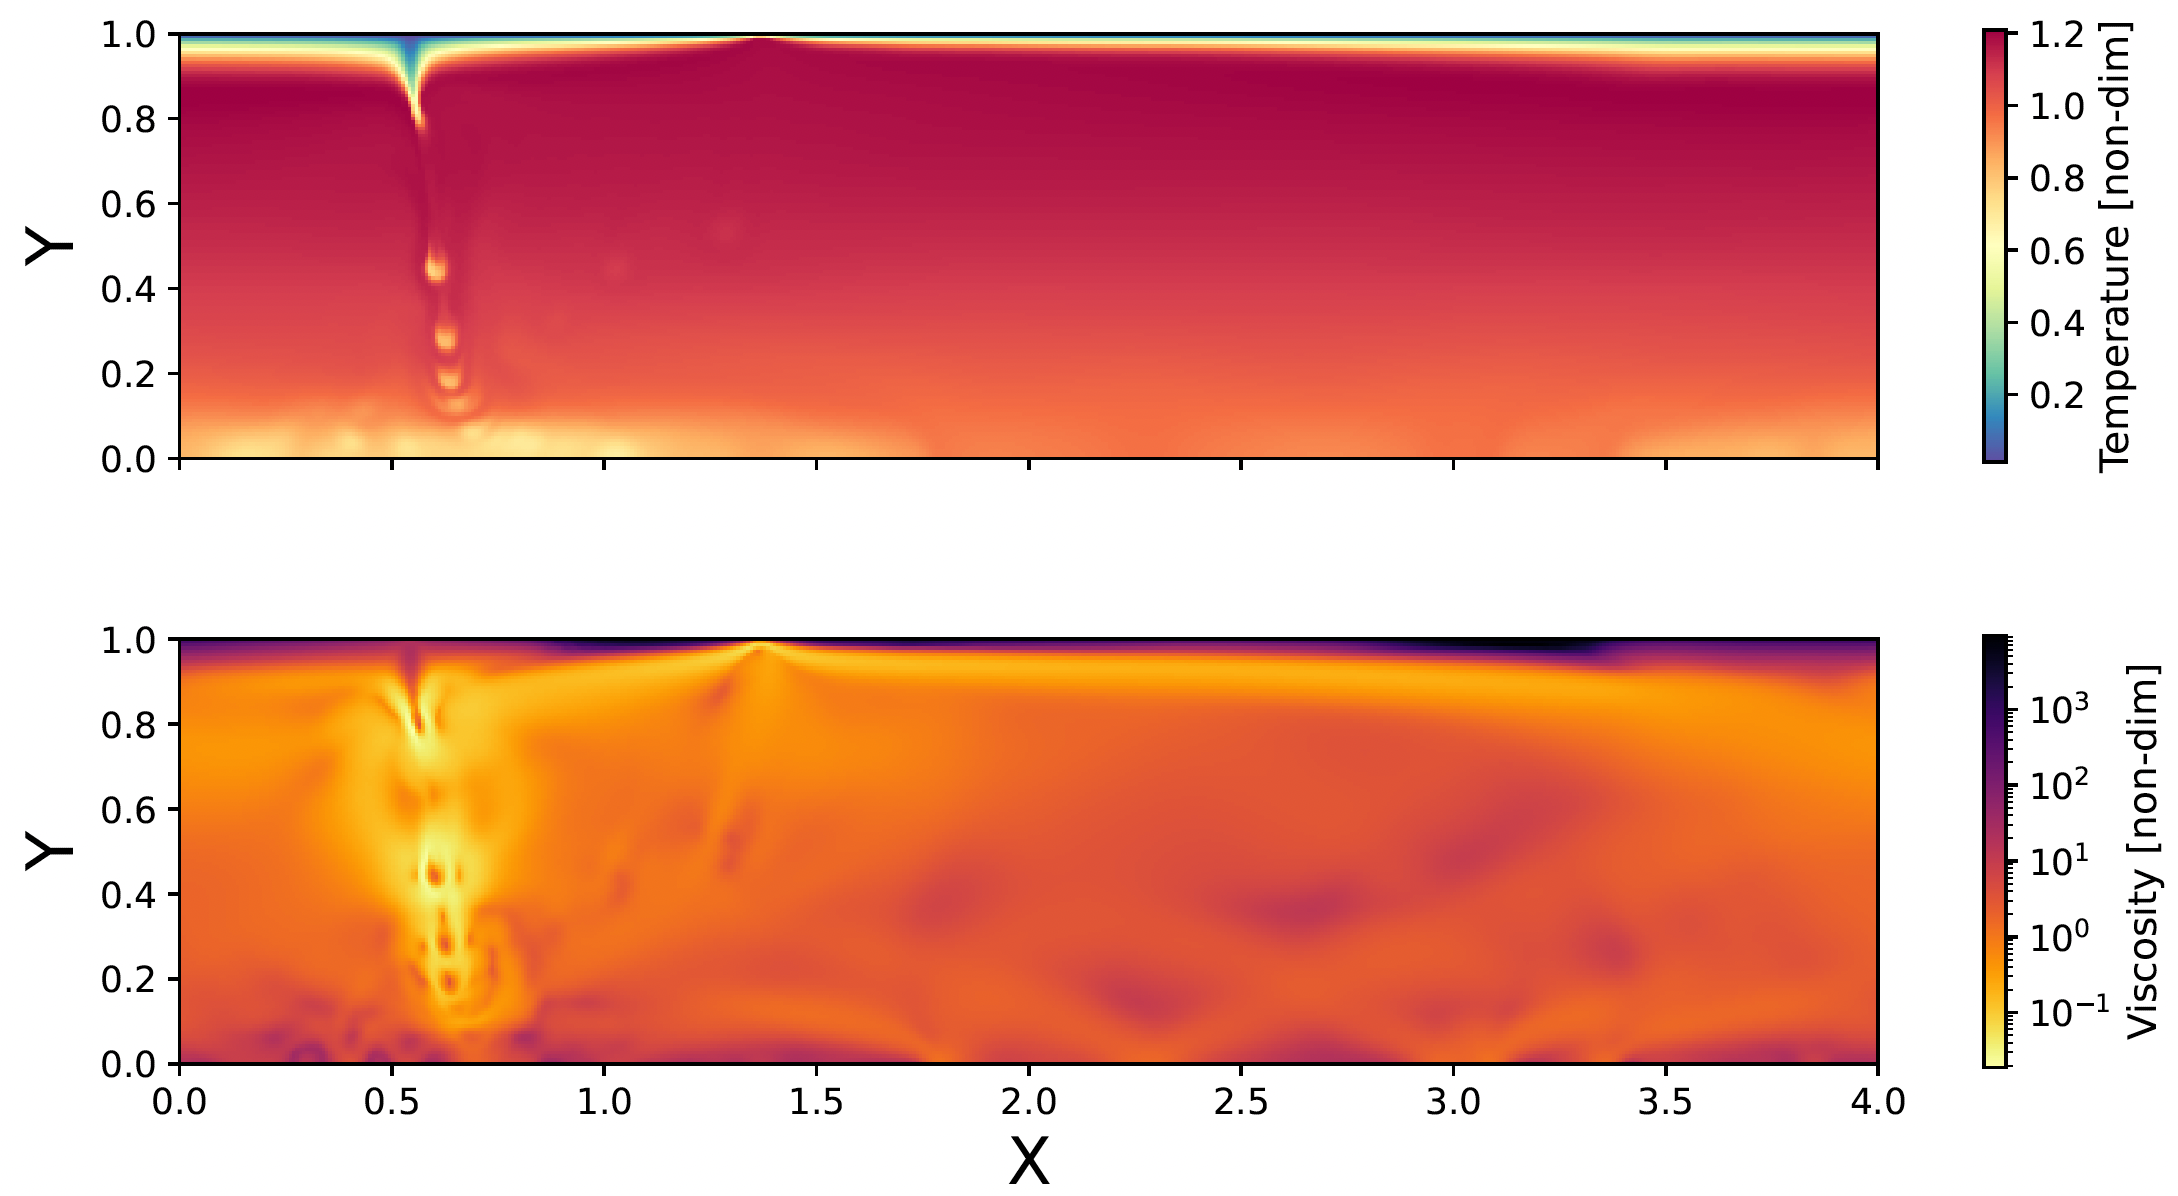

In [7]:
from google.colab import files
files.upload()
convection = np.loadtxt("f000", usecols=(0,1,2,5), unpack=True)

Saving f000 to f000


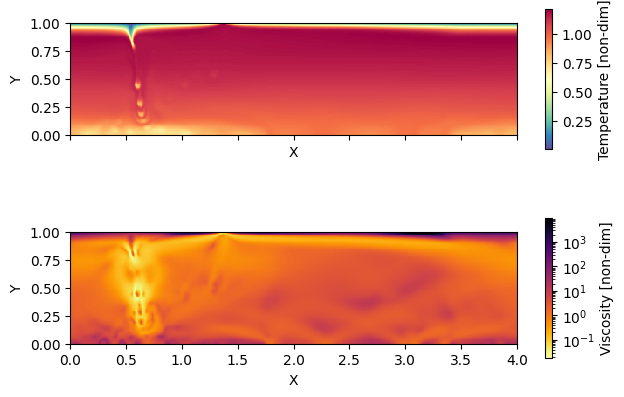

In [8]:
x = np.linspace(0,4,513)
y = np.linspace(0,1,129)
temp = convection[2]
visc = convection[3]

x_grid, y_grid = np.meshgrid(x, y, indexing="xy")
temp_grid = np.reshape(temp, (128,512), order="F")
visc_grid = np.reshape(visc, (128,512), order="F")

fig, (axis1, axis2) = plt.subplots(2, 1, sharex=True, layout="tight")

pcm = axis1.pcolormesh(x_grid, y_grid, temp_grid, cmap="Spectral_r")
axis1.set_box_aspect(0.25)
axis1.set_xlabel("X")
axis1.set_ylabel("Y")
cb=fig.colorbar(pcm, ax=axis1, shrink= 0.6)
cb.set_label(label="Temperature [non-dim]")

pcm = axis2.pcolormesh(x_grid, y_grid, visc_grid, cmap="inferno_r", norm="log")
axis2.set_box_aspect(0.25)
axis2.set_xlabel("X")
axis2.set_ylabel("Y")
cb=fig.colorbar(pcm, ax=axis2, shrink=0.6)
cb.set_label(label="Viscosity [non-dim]")

plt.show()

**Question 3.** Calculate horizontal average of viscosity at each depth, and plot this as a line plot with a logscale for viscosity. In other words, at each depth, y, you will average all of the viscosity values across x (for x from 0 to 4) at that depth. You should therefore end up with a 1-D array of average viscosities, with the same length as y.

Another way to think about this is that you will have a 2-D array with 512 columns and 128 rows after reshaping the original data to be able to plot the image. The columns represent $x$ and the rows represent $y$. In each row you will average all of the values in all the columns for that row, then move to the next row and so on.

You can get the $y$ value that corresponds to each of the 128 rows by:

`y=convec_data[0:128,1]`

for a case where we have loaded the entire f000 file in with the variable name `convec_data`. There should be 128 elements in this 1-D array `y` going from slightly larger than 0 to slightly less than 1.

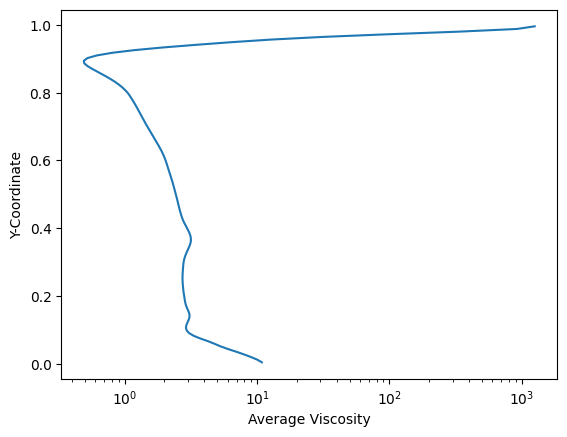

In [9]:
from logging import log
avg_visc = []
for i in range(128):
  avg_visc.append(np.average(visc_grid[i]))

y_v = convection[1,0:128]

plt.semilogx(avg_visc, y_v)
plt.xlabel("Average Viscosity")
plt.ylabel("Y-Coordinate")

plt.show()

# Plotting a Topographic Map

**Question 4.** Now we will make a simple topographic map, using the topographic data we worked with last time (topo.dat). You will need to make a latitude and longitude grid, and then interpolate the elevation data points we have in the file to that grid to plot.

You can use linspace commands to create 1-D arrays for latitude and longitude, then meshgrid to create latitude and longitude grids for creating a map.

Here's an example of making the latitude and longitude 1-D arrays:
`latitude=np.linspace(min(topo[:,0]),max(topo[:,0]),300)
longitude=np.linspace(min(topo[:,1]),max(topo[:,1]),720)`
Using 300 data points for latitude and 720 for longitude.

The final step of processing the data is to interpolate our topographic data to the grid we created. You can use the "griddata" function in the "scipy" package for this. Look up how that function works and check my explanation and example in the lecture notebook.

You'll load the function using code like:
`from scipy.interpolate import griddata`

In [10]:
from google.colab import files
files.upload()
topo = np.loadtxt('topo.dat',usecols=(0,1,2), unpack=True)

Saving topo.dat to topo.dat


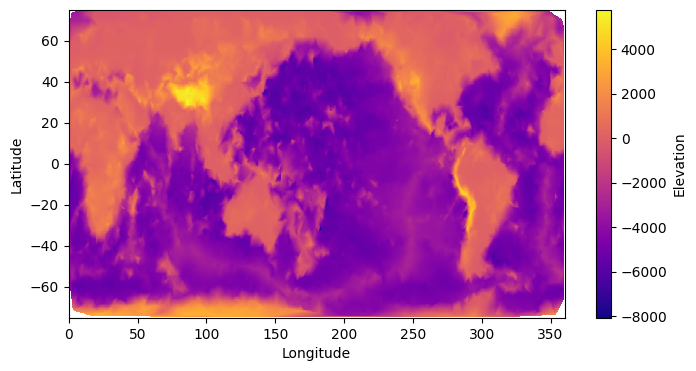

In [11]:
longitude = topo[1]
latitude = topo[0]
lon = np.linspace(min(topo[1]),max(topo[1]), 1000)
lat = np.linspace(min(topo[0]), max(topo[0]), 500)
elevation = topo[2]

lon_grid, lat_grid = np.meshgrid(lon, lat, indexing="xy")
elev_grid = griddata((longitude,latitude), elevation, (lon_grid, lat_grid), method="linear")

plt.figure(figsize=(8,4))
plt.pcolormesh(lon_grid, lat_grid, elev_grid, cmap="plasma")
cb = plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
cb.set_label(label="Elevation")

plt.show()

**Question 5.** Add a contour line at an elevation of 0 to mark the coastlines. You can try adding other contour lines to help show other features on the map.

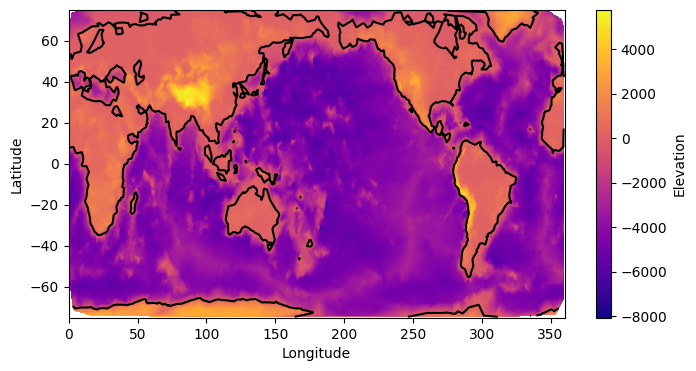

In [12]:
longitude = topo[1]
latitude = topo[0]
lon = np.linspace(min(topo[1]),max(topo[1]), 1000)
lat = np.linspace(min(topo[0]), max(topo[0]), 500)
elevation = topo[2]

lon_grid, lat_grid = np.meshgrid(lon, lat, indexing="xy")
elev_grid = griddata((longitude,latitude), elevation, (lon_grid, lat_grid), method="linear")

plt.figure(figsize=(8,4))
plt.pcolormesh(lon_grid, lat_grid, elev_grid, cmap="plasma")
cb = plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
cb.set_label(label="Elevation")

plt.contour(lon_grid, lat_grid, elev_grid, levels=[0], colors='black')

plt.show()

**Bous Question.** Try to plot the temperature anomaly each month\\\, using the file "world_temp_month.csv" in the style like the plot below. This will take some thought about how plot each year as a seperate line color coded by year.

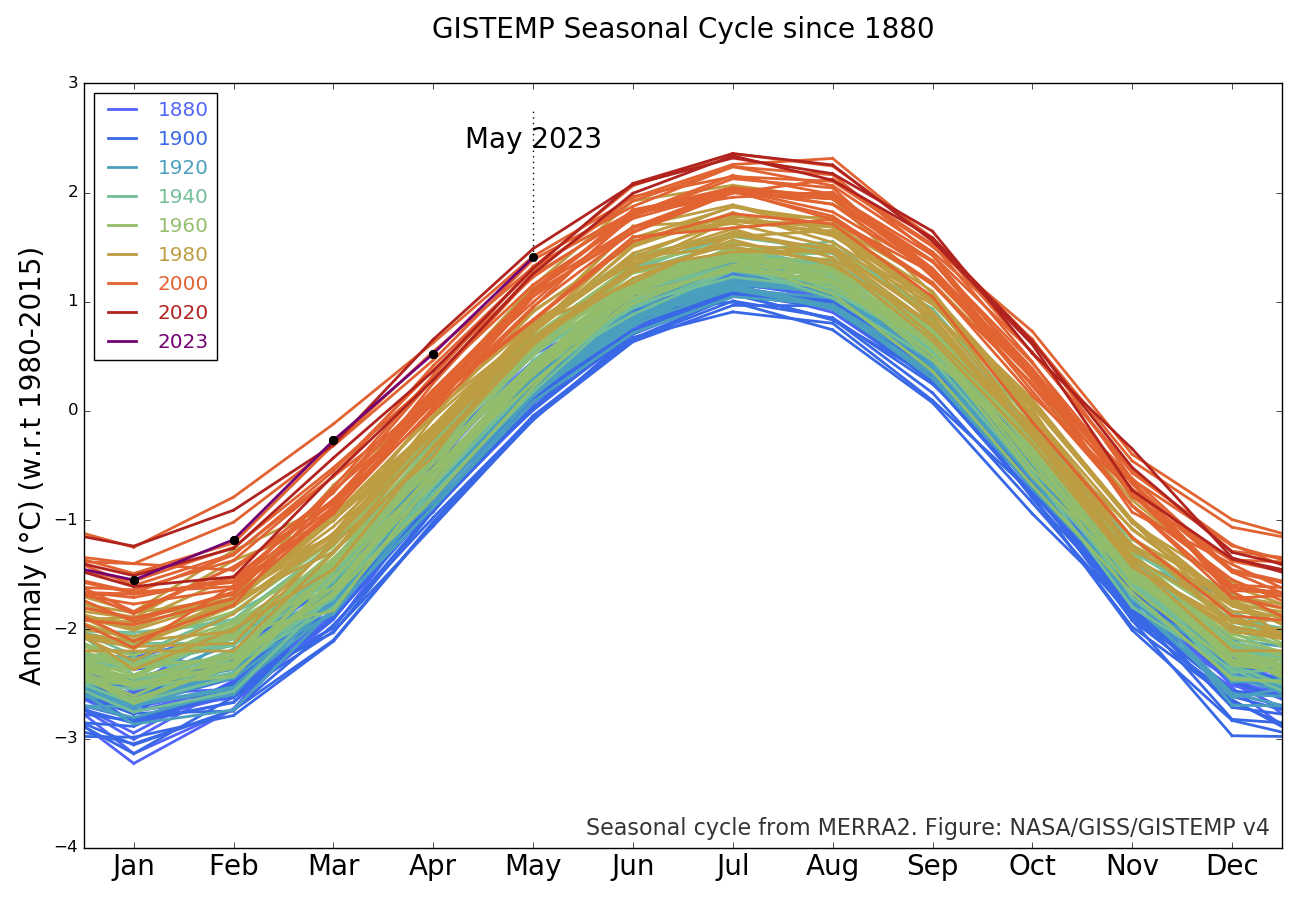

In [13]:
from google.colab import files
files.upload()
w_temp = np.loadtxt('world_temp_month.csv', usecols=(0,1), skiprows=2, delimiter=",", unpack=True)

Saving world_temp_month.csv to world_temp_month.csv


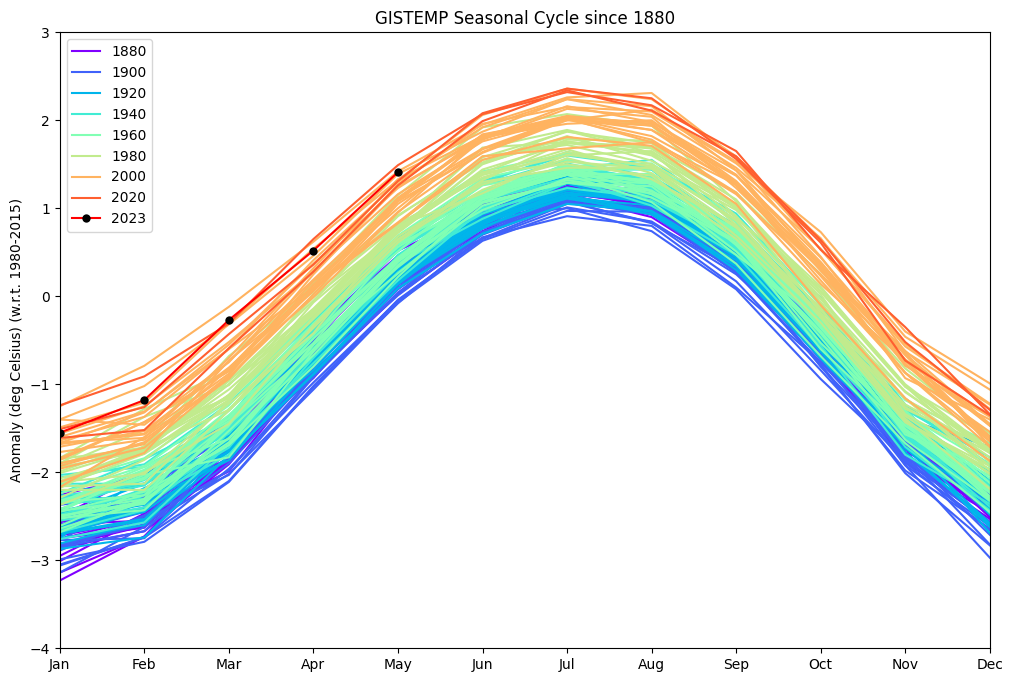

In [14]:
yrs = [str(a).split(".")[0] for a in w_temp[0]]
months = np.linspace(0,1,12)
unq = np.unique(yrs)[0::20]

decs = [a for a in unq for b in range(20) if a != "2020"]
decs = np.append(decs, [unq[len(unq)-1] for c in range(3)])
decs = np.append(decs, yrs[(len(w_temp[0])-5):len(w_temp[0])])
unq2 = np.append(unq, decs[len(decs)-1])
decs2 = np.array([])
for n in range(len(unq)-1):
  lst = np.concat((np.array([unq2[n]]), ("_" + decs[1+20*n:20*(n+1)])))
  decs2 = np.hstack((decs2,lst))
yr20 = 20*(len(unq2)-2)
lst2 = np.concat((np.array([unq2[len(unq2)-2]]), ("_" + decs[1+yr20:yr20+3])))
decs2 = np.hstack((decs2,lst2))


clrs = mpl.colormaps["rainbow"]
map = clrs(np.linspace(0,1,(len(unq2))))
cmap = [clr for clr in map[0:len(map)-2] for a in range(20)]
cmap = np.append(cmap, [map[len(map)-2] for b in range(3)])
cmap = np.append(cmap, map[len(map)-1])

fig, ax = plt.subplots(figsize=(12,8))

for n in range(int((len(w_temp[0])-5)/12)):
  ax.plot(months, w_temp[1][12*n:12*(n+1)], label=decs2[n], color=cmap[4*n:4*(n+1)])
ax.plot(months[0:5], w_temp[1][(len(w_temp[0])-5):len(w_temp[0])], label=unq2[len(unq)],
        color=cmap[len(cmap)-4:len(cmap)], marker='o', markerfacecolor="black", markeredgewidth=0)

ax.legend(loc="upper left")
ax.set(xlim=(0,1), ylim=(-4,3), xticks=np.linspace(0,1,12), ylabel="Anomaly (deg Celsius) (w.r.t. 1980-2015)",
       xticklabels=("Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"))
ax.set_title("GISTEMP Seasonal Cycle since 1880")

plt.show()

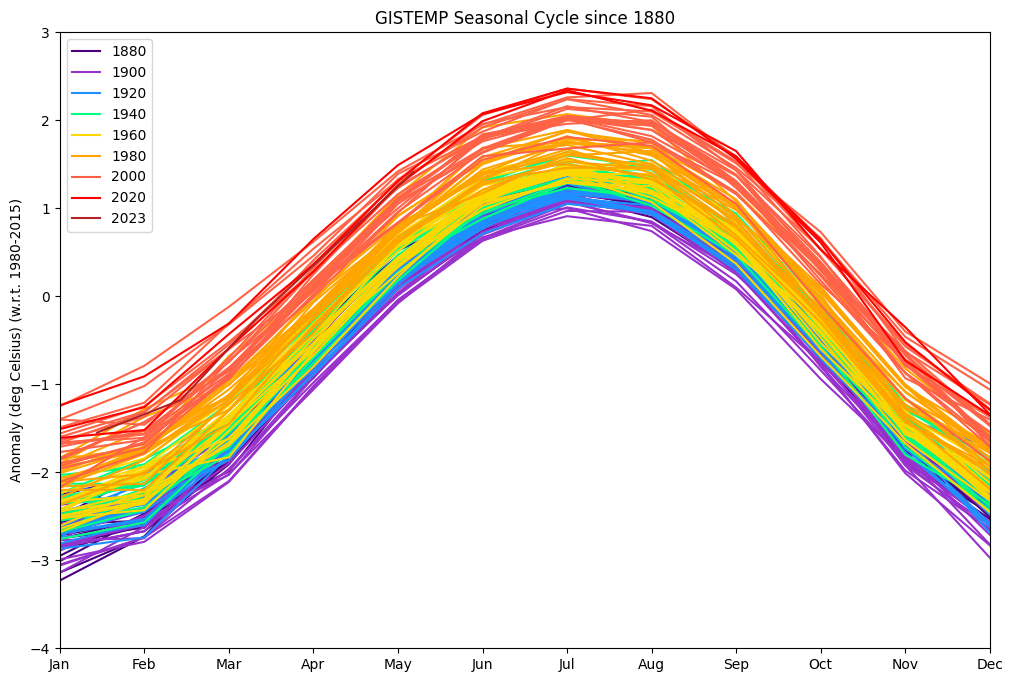

In [27]:
year = w_temp[0]
temp = w_temp[1]
months = np.linspace(0,1,12)


fig = plt.figure(figsize=(12,8))

for i in range(0, 20):
  lbl = ["1880" if i == 0 else "_1880"]
  plt.plot(months, temp[(12*i):(12*(i+1))], color="indigo", label=lbl[0])
for i in range(20,40):
  lbl = ["1900" if i == 20 else "_1900"]
  plt.plot(months, temp[(12*i):(12*(i+1))], color="darkorchid", label=lbl[0])
for i in range(40,60):
  lbl = ["1920" if i == 40 else "_1920"]
  plt.plot(months, temp[(12*i):(12*(i+1))], color="dodgerblue", label=lbl[0])
for i in range(60,80):
  lbl = ["1940" if i == 60 else "_1940"]
  plt.plot(months, temp[(12*i):(12*(i+1))], color="springgreen", label=lbl[0])
for i in range(80,100):
  lbl = ["1960" if i == 80 else "_1960"]
  plt.plot(months, temp[(12*i):(12*(i+1))], color="gold", label=lbl[0])
for i in range(100,120):
  lbl = ["1980" if i == 100 else "_1980"]
  plt.plot(months, temp[(12*i):(12*(i+1))], color="orange", label=lbl[0])
for i in range(120,140):
  lbl = ["2000" if i == 120 else "_2000"]
  plt.plot(months, temp[(12*i):(12*(i+1))], color="tomato", label=lbl[0])
for i in range(140,143):
  lbl = ["2020" if i == 140 else "_2020"]
  plt.plot(months, temp[(12*i):(12*(i+1))], color="red", label=lbl[0])

y_2023 = (np.array(year[(len(year)-5):len(year)]).astype(float) - 2023)
plt.plot(y_2023, temp[(len(temp)-5):len(temp)], color="firebrick", label="2023")

plt.legend(loc="upper left")
plt.ylabel("Anomaly (deg Celsius) (w.r.t. 1980-2015)")
plt.xlim(0,1)
plt.ylim(-4,3)
plt.xticks(np.linspace(0,1,12), labels=("Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"))
plt.title("GISTEMP Seasonal Cycle since 1880")

plt.show()